In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ANALYSIS_DIR_CANDIDATES = [
    Path('rotation_data'),
    Path('analysis') / 'rotation_data',
]
ANALYSIS_DIR = next(
    (path for path in ANALYSIS_DIR_CANDIDATES if path.is_dir()),
    None,
)
if ANALYSIS_DIR is None:
    raise FileNotFoundError(
        'Could not find rotation_data. Run from the repository root or analysis directory.'
    )

SYSTEM_FILES = {
    'CH1 PE': {
        'CH1': ANALYSIS_DIR / 'CH1_pointed_CH1_endtoend_rotation_deg.xvg',
        'CH2': ANALYSIS_DIR / 'CH1_pointed_CH2_endtoend_rotation_deg.xvg',
    },
    'CH1 reverse-face': {
        'CH1': ANALYSIS_DIR / 'CH1_reverseface_CH1_endtoend_rotation_deg.xvg',
        'CH2': ANALYSIS_DIR / 'CH1_reverseface_CH2_endtoend_rotation_deg.xvg',
    },
    'CH2 PE': {
        'CH1': ANALYSIS_DIR / 'CH2_pointed_CH1_endtoend_rotation_deg.xvg',
        'CH2': ANALYSIS_DIR / 'CH2_pointed_CH2_endtoend_rotation_deg.xvg',
    },
    'CH2 reverse-face': {
        'CH1': ANALYSIS_DIR / 'CH2_reverseface_CH1_endtoend_rotation_deg.xvg',
        'CH2': ANALYSIS_DIR / 'CH2_reverseface_CH2_endtoend_rotation_deg.xvg',
    },
}

ORIENTATIONS = ['CH1 PE', 'CH1 reverse-face', 'CH2 PE', 'CH2 reverse-face']
DOMAIN_COLORS = {'CH1': '#F21F46', 'CH2': '#F2A45E'}

PLOT_TITLE = None
PANEL_TITLES = {
    'CH1 PE': 'CH1 Pointed End',
    'CH1 reverse-face': 'CH1 Reverse Face',
    'CH2 PE': 'CH2 Pointed End',
    'CH2 reverse-face': 'CH2 Reverse Face',
}
X_LABEL = 'Time (ns)'
Y_LABEL = 'Angle from initial vector (°)'
X_LIM = (0, 1000)
Y_LIM = (0, 180)
X_TICKS = np.arange(200, 1001, 200)
Y_TICKS = np.arange(0, 181, 30)

FIGSIZE = (12, 3.5)
FIG_DPI = 300
LINEWIDTH = 1.8
SPINE_WIDTH = 1.5
TICK_LENGTH = 0
FONT_FAMILY = 'DejaVu Sans'
FONT_WEIGHT = 'normal'
TITLE_FONTSIZE = 11
LABEL_FONTSIZE = 10
TICK_FONTSIZE = 9
LEGEND_FONTSIZE = 8

plt.rcParams.update({
    'font.family': FONT_FAMILY,
    'font.weight': FONT_WEIGHT,
    'axes.labelweight': FONT_WEIGHT,
    'axes.titleweight': FONT_WEIGHT,
    'axes.linewidth': SPINE_WIDTH,
    'xtick.labelsize': TICK_FONTSIZE,
    'ytick.labelsize': TICK_FONTSIZE,
})


In [2]:
def read_xvg(path):
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if not line or line.startswith(('#', '@')):
                continue
            time_ps, angle_deg = map(float, line.split()[:2])
            rows.append((time_ps / 1000.0, angle_deg))
    return pd.DataFrame(rows, columns=['time_ns', 'angle_deg'])

angles = {}
for orientation, domains in SYSTEM_FILES.items():
    for domain, path in domains.items():
        angles[(orientation, domain)] = read_xvg(path)

summary = []
for (orientation, domain), data in angles.items():
    summary.append({
        'orientation': orientation,
        'domain': domain,
        'mean_angle_deg': data['angle_deg'].mean(),
        'maximum_angle_deg': data['angle_deg'].max(),
        'last_angle_deg': data['angle_deg'].iloc[-1],
        'late_mean_angle_deg': data.loc[data['time_ns'] >= 800, 'angle_deg'].mean(),
    })

angle_summary = pd.DataFrame(summary)
display(angle_summary)


,orientation,domain,mean_angle_deg,maximum_angle_deg,last_angle_deg,late_mean_angle_deg
0,CH1 PE,CH1,57.283181,116.105,33.319,46.837381
1,CH1 PE,CH2,30.811596,53.968,37.072,29.025952
2,CH1 reverse-face,CH1,115.732768,157.723,125.841,126.037842
3,CH1 reverse-face,CH2,101.551141,131.337,126.350,125.846526
4,CH2 PE,CH1,34.885000,82.748,47.741,31.394238
5,CH2 PE,CH2,33.626812,62.501,36.806,38.200810
6,CH2 reverse-face,CH1,81.682475,118.885,97.972,80.457095
7,CH2 reverse-face,CH2,42.647505,94.751,39.093,40.544333


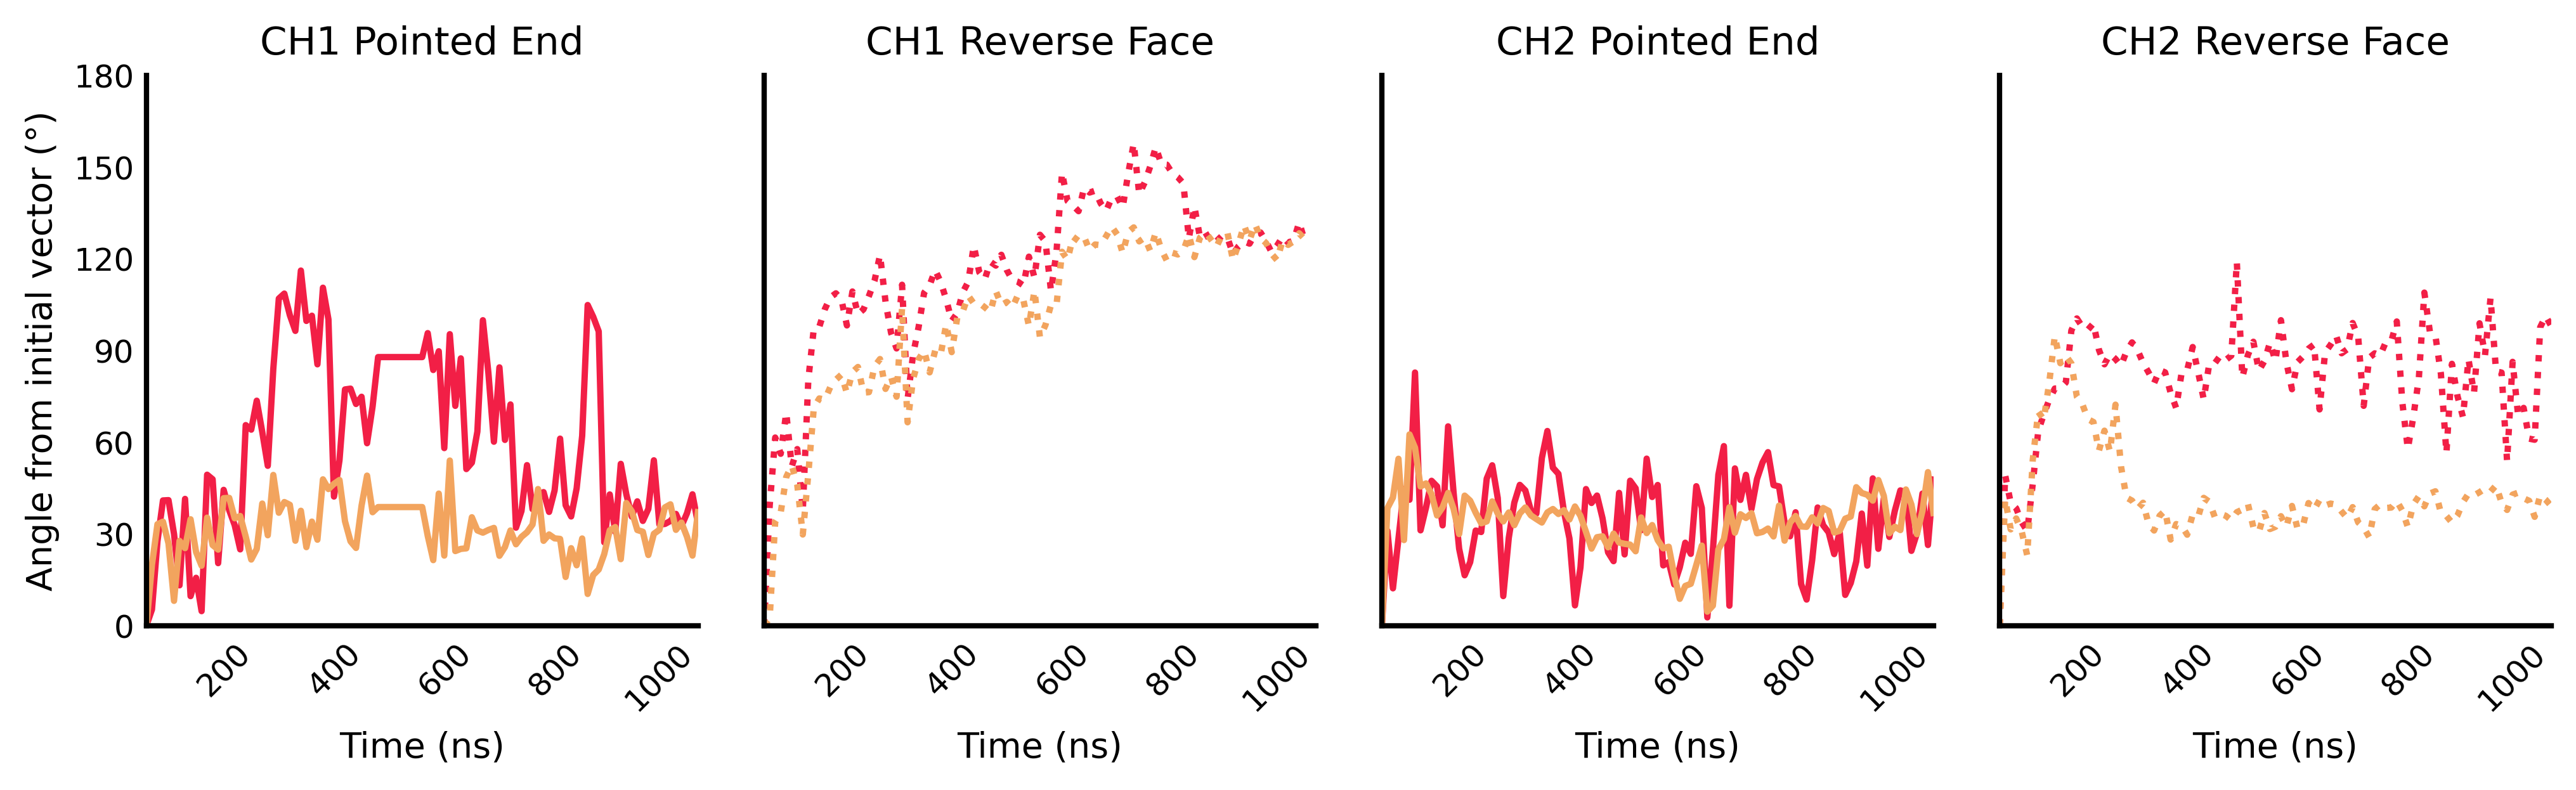

In [3]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=FIGSIZE,
    sharey=True,
    dpi=400,
)

for ax, orientation in zip(axes, ORIENTATIONS):
    line_style = ':' if 'reverse-face' in orientation else '-'
    for domain in ['CH1', 'CH2']:
        data = angles[(orientation, domain)]
        ax.plot(
            data['time_ns'],
            data['angle_deg'],
            color=DOMAIN_COLORS[domain],
            linestyle=line_style,
            linewidth=LINEWIDTH,
        )

    ax.set_title(
        PANEL_TITLES[orientation],
        fontsize=TITLE_FONTSIZE,
        fontweight=FONT_WEIGHT,
        pad=6,
    )
    ax.set_xlabel(
        X_LABEL,
        fontsize=LABEL_FONTSIZE,
        fontweight=FONT_WEIGHT,
    )
    ax.set_xticks(X_TICKS)
    ax.set_yticks(Y_TICKS)
    ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=TICK_LENGTH,
        width=0,
        labelsize=TICK_FONTSIZE,
    )
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
        label.set_fontweight(FONT_WEIGHT)
    for label in ax.get_yticklabels():
        label.set_fontweight(FONT_WEIGHT)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(SPINE_WIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_WIDTH)
    if X_LIM is not None:
        ax.set_xlim(X_LIM)
    if Y_LIM is not None:
        ax.set_ylim(Y_LIM)

legend_handles = [
    Line2D(
        [0], [0],
        color=DOMAIN_COLORS['CH1'],
        linestyle='-',
        linewidth=LINEWIDTH,
        label='CH1',
    ),
    Line2D(
        [0], [0],
        color=DOMAIN_COLORS['CH2'],
        linestyle='-',
        linewidth=LINEWIDTH,
        label='CH2',
    ),
]
'''
fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.2,
)
'''
axes[0].set_ylabel(
    Y_LABEL,
    fontsize=LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT,
)
fig.subplots_adjust(
    left=0.08,
    right=0.87,
    bottom=0.28,
    top=0.90,
    wspace=0.12,
)
plt.show()
